<a href="https://colab.research.google.com/github/kowsik005/ml_supervised_project/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Random Forest Evaluation ---
Mean Squared Error (MSE): 3.85
R² Score: 0.8392

--- Feature Importance ---
         Feature  Importance
Random_Feature_1    0.626673
Random_Feature_0    0.336318
Random_Feature_5    0.009382
Random_Feature_3    0.007818
Random_Feature_4    0.005953
Random_Feature_2    0.005119
Random_Feature_7    0.004845
Random_Feature_6    0.003891


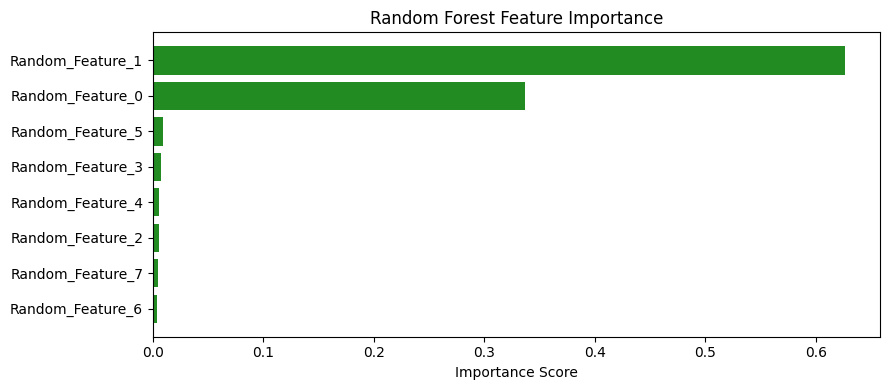

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate purely random numbers in memory
np.random.seed(42)
n_samples = 300
n_features = 8

# Generate random feature matrix X
X_raw = np.random.randn(n_samples, n_features)

# Define target y with non-linear relationships (Feature 0 squared + Feature 1 interaction)
y_raw = (3 * (X_raw[:, 0] ** 2)) - (5 * X_raw[:, 1]) + np.random.randn(n_samples) * 1.5

feature_names = [f'Random_Feature_{i}' for i in range(n_features)]
X = pd.DataFrame(X_raw, columns=feature_names)
y = pd.Series(y_raw, name='Target')

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train Random Forest Regressor
# n_estimators controls the number of decision trees in the forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluate Model Performance
y_pred = rf_model.predict(X_test)

print("--- Random Forest Evaluation ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}\n")

# 5. Extract Feature Importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importance ---")
print(importance_df.to_string(index=False))

# 6. Plot Feature Importance Bar Chart
plt.figure(figsize=(9, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()